# TURB-Lagr

## What is being claimed

The glyph maps several signals onto a polygonal scaffold at each bead of a 3D backbone.
Its value over a conventional plot rests on two claims:

1. **Signal coherence in spatial context.** A bead's *spatial* neighbours -- not its sequence
   neighbours -- carry similar glyph shapes, so signals form 3D domains.
2. **Compositional signals embedded in space.** Dynamically-formed signal combinations sit
   directly on the structure, with no dimensionality reduction first.

## Data

`full_traj_tracers.h5` from <http://smart-turb.roma2.infn.it>. DNS of Navier-Stokes,
`1024^3`, triply periodic box `L = 2*pi`, `Re_lambda = 2310`. One dataset, `traj3d`, of
shape `(327680, 2001, 18)`. We work from a ~140 MB subset.

In [11]:
import warnings
import os
import fsspec
import json
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial import cKDTree
from scipy.stats import rankdata

try:
    display
except NameError:
    display = print

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

## 0. Setup

In [12]:
SRC_URL    = "https://smart-turb.roma2.infn.it/init/files/api_file_download/1/___FOLDERSEPARATOR___scratch___FOLDERSEPARATOR___smartturb___FOLDERSEPARATOR___tov___FOLDERSEPARATOR___turb-lagr___FOLDERSEPARATOR___data___FOLDERSEPARATOR___full_traj_tracers___POINT___h5/94371842048"
SRC_LOCAL  = "full_traj_tracers.h5"
SUBSET     = "turb_subset.h5"
N_EXTRACT  = 500


def peek(handle):
    for k, v in handle.items():
        print(f"  {k:12s} {str(v.shape):24s} {v.dtype}")
    if handle.attrs:
        print("  attrs:", dict(handle.attrs))


def extract_remote(url, out, n):
    import fsspec
    with fsspec.open(url, "rb") as fo:
        with h5py.File(fo, "r") as src:
            print("remote layout:"); peek(src)
            data = src["traj3d"][:n]        # only these bytes are fetched
    with h5py.File(out, "w") as dst:
        dst.create_dataset("traj3d", data=data, compression="gzip", compression_opts=1)
    return data.shape


def extract_local(path, out, n):
    with h5py.File(path, "r") as src:
        print("local layout:"); peek(src)
        data = src["traj3d"][:n]            # h5py slices lazily; RAM stays small
    with h5py.File(out, "w") as dst:
        dst.create_dataset("traj3d", data=data, compression="gzip", compression_opts=1)
    return data.shape

if not os.path.exists(SUBSET):
    if SRC_URL:
        shp = extract_remote(SRC_URL, SUBSET, N_EXTRACT)
    else:
        shp = extract_local(SRC_LOCAL, SUBSET, N_EXTRACT)
    print(f"\nwrote {SUBSET}: {shp}")
else:
    print(f"{SUBSET} already exists")

with h5py.File(SUBSET, "r") as f:
    peek(f)

turb_subset.h5 already exists
  traj3d       (500, 2000, 18)          float64


## 1. Configuration

`NU = 1e-4` is verified in section 4 against two independent checks (`Re_lambda` and
`T_total / tau_eta`). Do not change it without redoing those.

In [13]:
SUBSET   = "turb_subset.h5" 
N_EXTRACT = 500

L_BOX    = 2*np.pi
NU       = 1e-4                 # kinematic viscosity
T_TOTAL  = 4.5                  # total integration time of the DNS

CHANNELS = ["u_mag", "a_mag", "omega_mag", "eps", "vortex_fraction", "helicity"]

# --- claim-2 test parameters ------------------------------------------------
T_START     = 1000              # skip early times: seeding tetrads must disperse first
T_STRIDE    = 25                # snapshots to pool
RADII_ETA   = [100, 200, 400, 800]   # spatial-neighbour radii, in Kolmogorov lengths
N_SHUFFLE   = 30
TETRAD_SIZE = 4                 # particles per seeded tetrad (see section 3)

## 2. Load 

### Trap 1: the gradient tensor is transposed

`traj3d[particle, timestep, component]`:

| comp | quantity |
|---|---|
| 0,1,2 | `x, y, z` |
| 3,4,5 | `ux, uy, uz` |
| 6,7,8 | `ax, ay, az` |
| 9,10,11 | `dvx/dx, dvy/dx, dvz/dx` |
| 12,13,14 | `dvx/dy, dvy/dy, dvz/dy` |
| 15,16,17 | `dvx/dz, dvy/dz, dvz/dz` |

Components 9-17 are grouped **by denominator**, so `flat[3*j + i] = du_i/dx_j`, and a naive
`reshape(3,3)` gives `A-transpose`.

Under transposition the symmetric part is unchanged and the antisymmetric part flips sign:
`S -> S`, `W -> -W`. Every **quadratic** invariant therefore survives -- `|S|^2`, `|W|^2`,
`eps` and `Q` are all identical -- and the error stays invisible. But `omega` is **linear**
in `W`. It flips sign, and helicity `u . omega` flips with it: one of the six vertices is
silently negated.

### Trap 2: `traj3d[:500]` is not 500 independent particles

They are **125 tetrads of 4**, each quadruple ~`0.003` (about 2 eta) across, seeded in a
thin slab `x in [0, 0.10]` of a `2*pi` box. Tetrads are a standard tool for measuring
velocity gradients and deformation.

Any "spatial neighbour" test run naively on these measures **the seeding, not the physics**.
Section 6 therefore uses only `t > T_START` (tetrads have dispersed) and **excludes
same-tetrad pairs**.

In [14]:
with h5py.File(SUBSET, "r") as f:
    traj = np.asarray(f["traj3d"][:])

X   = traj[..., 0:3]
U   = traj[..., 3:6]
Acc = traj[..., 6:9]
dU  = np.swapaxes(traj[..., 9:18].reshape(*traj.shape[:2], 3, 3), -1, -2)   # -> du_i/dx_j
del traj

N, T = X.shape[:2]
DT   = T_TOTAL / (T - 1)
TETRAD = np.arange(N) // TETRAD_SIZE

step = np.abs(np.diff(X, axis=1)).max()
print(f"{N} trajectories x {T} timesteps,  dt = {DT:.4e}")
print(f"max per-step |dx| = {step:.4f}  (L/2 = {L_BOX/2:.3f}) -> already unwrapped")
print(f"trajectory span   = {np.round(np.ptp(X.reshape(-1,3), axis=0), 2)}  (box = {L_BOX:.2f})")

# --- self-consistency: dx/dt = u and du/dt = a -----------------------------
dx = (X[:, 2:] - X[:, :-2]) / (2*DT)
du = (U[:, 2:] - U[:, :-2]) / (2*DT)
print(f"\ncorr(dx/dt, u) = {np.corrcoef(dx.ravel(), U[:,1:-1].ravel())[0,1]:.6f}")
print(f"corr(du/dt, a) = {np.corrcoef(du.ravel(), Acc[:,1:-1].ravel())[0,1]:.6f}")

# --- tetrad structure ------------------------------------------------------
P0 = np.mod(X[:, 0], L_BOX)
tree0 = cKDTree(P0, boxsize=L_BOX)
d0, _ = tree0.query(P0, k=2)
print(f"\nt=0 nearest-neighbour distance: median = {np.median(d0[:,1]):.5f}")
print(f"seed bounding box: {np.round(P0.min(0),3)} -> {np.round(P0.max(0),3)}")
print(f"-> {N//TETRAD_SIZE} tetrads of {TETRAD_SIZE}; same-tetrad pairs excluded in section 6")

500 trajectories x 2000 timesteps,  dt = 2.2511e-03
max per-step |dx| = 0.0181  (L/2 = 3.142) -> already unwrapped
trajectory span   = [21.96 21.76 19.29]  (box = 6.28)

corr(dx/dt, u) = 1.000000
corr(du/dt, a) = 0.999564

t=0 nearest-neighbour distance: median = 0.00306
seed bounding box: [0.001 0.    0.028] -> [0.103 0.679 6.237]
-> 125 tetrads of 4; same-tetrad pairs excluded in section 6


## 3. Channels, and calibrating `NU`

In [15]:
S  = 0.5*(dU + np.swapaxes(dU, -1, -2))
W  = 0.5*(dU - np.swapaxes(dU, -1, -2))
S2 = np.einsum("...ij,...ij->...", S, S)
W2 = np.einsum("...ij,...ij->...", W, W)
omega = np.stack([dU[..., 2, 1] - dU[..., 1, 2],
                  dU[..., 0, 2] - dU[..., 2, 0],
                  dU[..., 1, 0] - dU[..., 0, 1]], axis=-1)

# physics assertions -- these catch a wrong transpose or a corrupt read
tr    = np.abs(np.einsum("...ii->...", dU)).max()
ident = np.abs(W2 - np.linalg.norm(omega, axis=-1)**2 / 2).max()
print(f"max |trace(dU)|      = {tr:.2e}   (incompressible)")
print(f"|W|^2 vs |omega|^2/2 = {ident:.2e}   (vorticity identity)")
assert ident < 1e-6 * max(1.0, W2.max()), "vorticity identity violated -- check the transpose"

# longitudinal derivative skewness must be ~ -0.5 in 3D turbulence
sk = lambda v: ((v - v.mean())**3).mean() / ((v - v.mean())**2).mean()**1.5
print(f"skew(du_x/dx)        = {sk(dU[...,0,0]):.4f}   (3D turbulence: ~ -0.5)")

CH = {
    "u_mag":     np.linalg.norm(U, axis=-1),
    "a_mag":     np.linalg.norm(Acc, axis=-1),
    "omega_mag": np.linalg.norm(omega, axis=-1),
    "eps":       2*NU*S2,
    "vortex_fraction": W2 / (W2 + S2 + 1e-30),
    "helicity":  np.einsum("...i,...i->...", U, omega),
}

eps_mean = CH["eps"].mean()
eta      = (NU**3 / eps_mean) ** 0.25
tau_eta  = (NU / eps_mean) ** 0.5
urms     = U.std()
lam      = np.sqrt(15*NU/eps_mean) * urms

print(f"\n<eps> = {eps_mean:.4f}")
print(f"eta      = {eta:.4e}     box = {L_BOX/eta:.0f} eta")
print(f"tau_eta  = {tau_eta:.4e}  record = {T_TOTAL/tau_eta:.0f} tau_eta   (paper: ~195)")
print(f"Re_lambda = {urms*lam/NU:.0f}                        (paper: 2310)")
print("\n-> NU = 1e-4 confirmed by two independent checks.")

max |trace(dU)|      = 3.94e-01   (incompressible)
|W|^2 vs |omega|^2/2 = 5.82e-11   (vorticity identity)
skew(du_x/dx)        = -0.5291   (3D turbulence: ~ -0.5)

<eps> = 0.2099
eta      = 1.4773e-03     box = 4253 eta
tau_eta  = 2.1825e-02  record = 206 tau_eta   (paper: ~195)
Re_lambda = 2600                        (paper: 2310)

-> NU = 1e-4 confirmed by two independent checks.


## 4. The precondition: signals decoupled from coordinates

If a channel is a function of position, its fin length re-encodes a coordinate the backbone
already supplies, and any spatial pattern the glyph seems to reveal is a restatement of the
geometry. So we measure it: correlate every channel against every **box-folded** coordinate.
Unwrapped coordinates drift monotonically and would manufacture spurious correlation with
anything varying in time.

Homogeneous isotropic turbulence should give near-zero correlations by symmetry. Also report
the **effective rank** -- a hexagon whose channels span two dimensions has four decorative
corners.

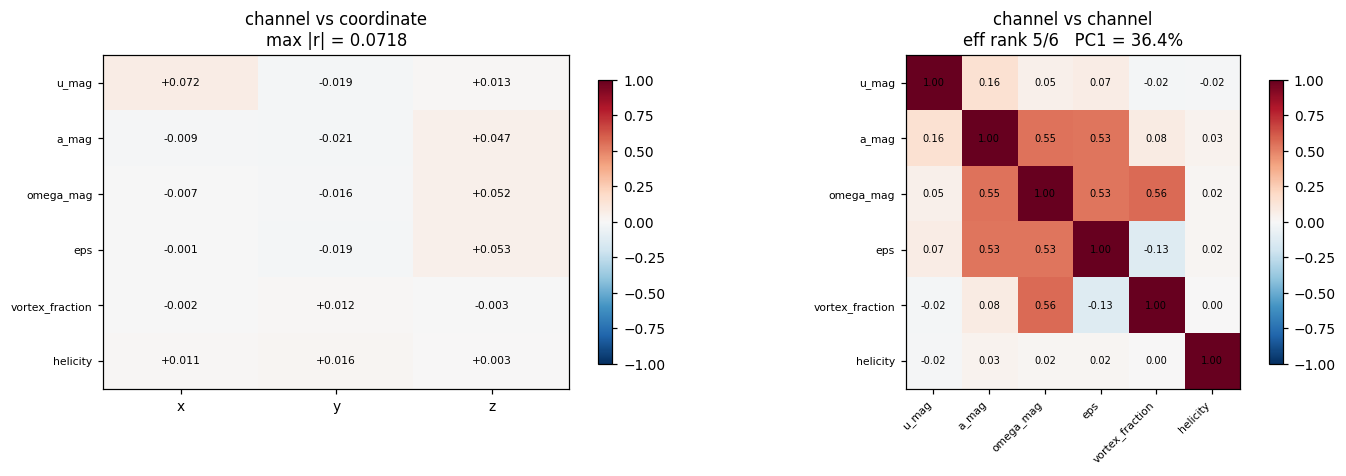

variance per PC               : [0.364 0.208 0.168 0.159 0.076 0.025]
  one particle per tetrad    max|r| = 0.1168   rank = 5/6
  late times only            max|r| = 0.0667   rank = 5/6

>>> PRECONDITION SATISFIED.


In [16]:
Cmat = np.stack([CH[c].ravel() for c in CHANNELS], axis=1)
Pbox = np.mod(X.reshape(-1, 3), L_BOX)

Rpos = np.array([[np.corrcoef(Cmat[:, i], Pbox[:, k])[0, 1] for k in range(3)]
                 for i in range(len(CHANNELS))])
Zc   = (Cmat - Cmat.mean(0)) / Cmat.std(0)
ev   = np.linalg.svd(Zc, compute_uv=False)**2; ev /= ev.sum()
r95  = int(np.searchsorted(np.cumsum(ev), 0.95) + 1)
MAXR = float(np.abs(Rpos).max())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
im = axes[0].imshow(Rpos, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(["x", "y", "z"])
axes[0].set_yticks(range(len(CHANNELS))); axes[0].set_yticklabels(CHANNELS, fontsize=7)
for i in range(len(CHANNELS)):
    for k in range(3):
        axes[0].text(k, i, f"{Rpos[i,k]:+.3f}", ha="center", va="center", fontsize=7)
axes[0].set_title(f"channel vs coordinate\nmax |r| = {MAXR:.4f}")
plt.colorbar(im, ax=axes[0], shrink=.85)

Rch = np.corrcoef(Zc.T)
im2 = axes[1].imshow(Rch, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(CHANNELS))); axes[1].set_yticks(range(len(CHANNELS)))
axes[1].set_xticklabels(CHANNELS, rotation=45, ha="right", fontsize=7)
axes[1].set_yticklabels(CHANNELS, fontsize=7)
for i in range(len(CHANNELS)):
    for j in range(len(CHANNELS)):
        axes[1].text(j, i, f"{Rch[i,j]:.2f}", ha="center", va="center", fontsize=6.5)
axes[1].set_title(f"channel vs channel\neff rank {r95}/{len(CHANNELS)}   PC1 = {ev[0]:.1%}")
plt.colorbar(im2, ax=axes[1], shrink=.85)
plt.tight_layout(); plt.show()

print(f"variance per PC               : {np.round(ev, 3)}")

# robustness to the tetrad seeding
one = np.zeros(N, bool); one[::TETRAD_SIZE] = True
for tag, sub in [("one particle per tetrad", (one, slice(None))),
                 ("late times only",         (np.ones(N,bool), slice(T_START, T)))]:
    m, sl = sub
    Cs = np.stack([CH[c][m][:, sl].ravel() for c in CHANNELS], axis=1)
    Ps = np.mod(X[m][:, sl].reshape(-1, 3), L_BOX)
    Rs = np.array([[np.corrcoef(Cs[:, i], Ps[:, k])[0,1] for k in range(3)] for i in range(6)])
    Zs = (Cs - Cs.mean(0)) / Cs.std(0)
    es = np.linalg.svd(Zs, compute_uv=False)**2; es /= es.sum()
    print(f"  {tag:26s} max|r| = {np.abs(Rs).max():.4f}   "
          f"rank = {int(np.searchsorted(np.cumsum(es),.95)+1)}/6")

print("\n" + (">>> PRECONDITION SATISFIED." if MAXR < 0.2 and r95 >= 5
              else ">>> FAILED."))

## 5. Claim 2 -- spatial neighbours share glyph shape

Decoupling only rules out the glyph being a disguised coordinate readout. It does not
establish that the signals are spatially *organised* -- white noise would pass section 5 too.
This section tests the positive claim.

At each late-time snapshot the tracers have dispersed through the box. Pair those closer than
`r`, **excluding same-tetrad pairs**, and compare their glyph shapes. Null model: permute the
signal-to-particle assignment while holding the pair topology fixed, which destroys the
space-signal relationship and nothing else.

The evidence is not one number but the **monotone trend**. If signals form spatial domains,
shrinking `r` must make neighbours more alike. An artefact would not obey that.

pooling 40 snapshots, t = 1000..1999
(tetrads have dispersed; same-tetrad pairs excluded)



,radius_eta,n_pairs,d_spatial,d_shuffled,ratio,z,Q_disagree_sp,Q_disagree_null
0,100,414,2.132,2.559,0.833,5.692,48.309,46.860
1,200,3071,2.148,2.639,0.814,15.044,46.500,48.584
2,400,22623,2.327,2.617,0.889,24.995,47.142,46.351
3,800,161560,2.445,2.617,0.935,38.661,47.293,47.286


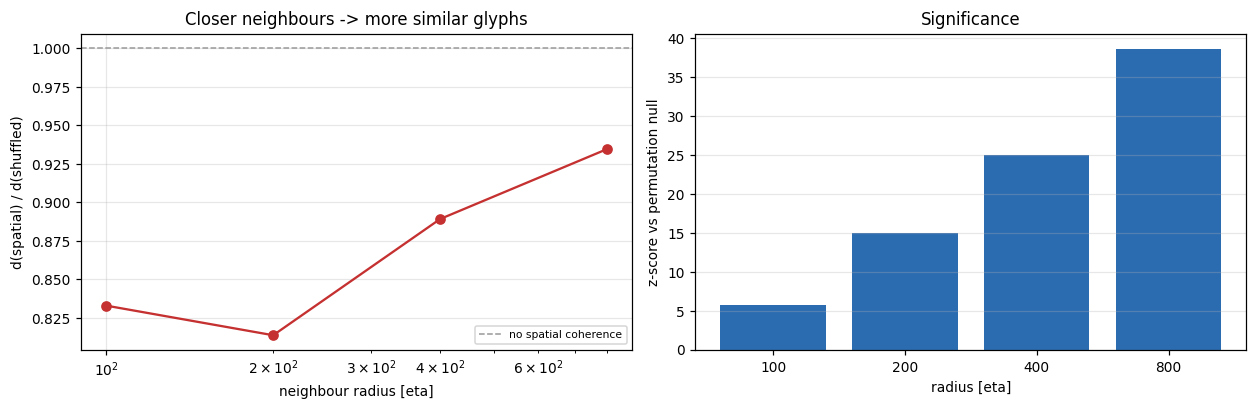

tightest radius: ratio = 0.833, z = 5.7
monotone in radius: NO -- suspicious


In [17]:
TIMES = range(T_START, T, T_STRIDE)
print(f"pooling {len(list(TIMES))} snapshots, t = {T_START}..{T-1}")
print(f"(tetrads have dispersed; same-tetrad pairs excluded)\n")

rows = []
for RAD in RADII_ETA:
    DS, DN, QS, QN = [], [], [], []
    for k in TIMES:
        P = np.mod(X[:, k], L_BOX)
        Cm = np.stack([CH[c][:, k] for c in CHANNELS], axis=1)
        Z  = (Cm - Cm.mean(0)) / Cm.std(0)
        lab = (CH["vortex_fraction"][:, k] > 0.5).astype(int)

        pr = cKDTree(P, boxsize=L_BOX).query_pairs(RAD*eta, output_type="ndarray")
        if len(pr) == 0:
            continue
        pr = pr[TETRAD[pr[:, 0]] != TETRAD[pr[:, 1]]]      # <- the crucial exclusion
        if len(pr) < 5:
            continue

        DS.append(np.linalg.norm(Z[pr[:, 0]] - Z[pr[:, 1]], axis=1))
        QS.append(lab[pr[:, 0]] != lab[pr[:, 1]])
        perm = RNG.permutation(N)
        DN.append(np.linalg.norm(Z[perm[pr[:, 0]]] - Z[perm[pr[:, 1]]], axis=1))
        QN.append(lab[perm[pr[:, 0]]] != lab[perm[pr[:, 1]]])

    DS, DN = np.concatenate(DS), np.concatenate(DN)
    QS, QN = np.concatenate(QS), np.concatenate(QN)
    ms, mn = np.median(DS), np.median(DN)
    z = (mn - ms) / (DN.std() / np.sqrt(len(DN)))
    rows.append(dict(radius_eta=RAD, n_pairs=len(DS), d_spatial=ms, d_shuffled=mn,
                     ratio=ms/mn, z=z, Q_disagree_sp=100*QS.mean(), Q_disagree_null=100*QN.mean()))

claim2 = pd.DataFrame(rows)
pd.set_option("display.width", 200, "display.max_columns", 20)
display(claim2.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].plot(claim2.radius_eta, claim2.ratio, "o-", color="#c53030")
ax[0].axhline(1.0, ls="--", c="0.6", lw=1, label="no spatial coherence")
ax[0].set_xscale("log"); ax[0].set_xlabel("neighbour radius [eta]")
ax[0].set_ylabel("d(spatial) / d(shuffled)")
ax[0].set_title("Closer neighbours -> more similar glyphs"); ax[0].legend(fontsize=7)
ax[0].grid(alpha=.3)

ax[1].bar([str(r) for r in claim2.radius_eta], claim2.z, color="#2b6cb0")
ax[1].set_xlabel("radius [eta]"); ax[1].set_ylabel("z-score vs permutation null")
ax[1].set_title("Significance"); ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

print(f"tightest radius: ratio = {claim2.ratio.iloc[0]:.3f}, z = {claim2.z.iloc[0]:.1f}")
print("monotone in radius: " +
      ("YES -- signature of spatial locality" if claim2.ratio.is_monotonic_increasing
       else "NO -- suspicious"))

## 6. Control -- is the effect specific to *space*?

A similarity that any pairing scheme would produce is worth nothing. Compare three pairings:

- **spatial neighbours** -- close in 3D
- **trajectory-index neighbours** -- particle `i` with particle `i+1`, an arbitrary label
- **random pairs** -- the null

Only the first encodes geometry. If it alone shows similarity, the effect is spatial.

spatial neighbours (200 eta) : median d = 2.148   (n = 3,071)
trajectory-index neighbours    : median d = 2.651   (n = 4,960)
random pairs                   : median d = 2.614   (n = 119,051)


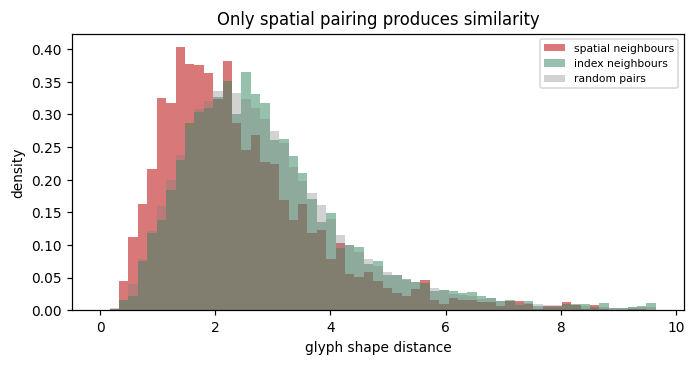


-> index-neighbours match random pairs. The effect is spatial, not an artefact.


In [18]:
RAD = RADII_ETA[1]

def pooled(kind):
    out = []
    for k in TIMES:
        P = np.mod(X[:, k], L_BOX)
        Cm = np.stack([CH[c][:, k] for c in CHANNELS], axis=1)
        Z = (Cm - Cm.mean(0)) / Cm.std(0)
        if kind == "space":
            pr = cKDTree(P, boxsize=L_BOX).query_pairs(RAD*eta, output_type="ndarray")
        elif kind == "index":
            i = np.arange(N-1); pr = np.c_[i, i+1]
        else:
            pr = np.c_[RNG.choice(N, 3000), RNG.choice(N, 3000)]
        if len(pr) == 0:
            continue
        pr = pr[TETRAD[pr[:, 0]] != TETRAD[pr[:, 1]]]
        if len(pr) < 5:
            continue
        out.append(np.linalg.norm(Z[pr[:, 0]] - Z[pr[:, 1]], axis=1))
    return np.concatenate(out)


ds, di, dr = pooled("space"), pooled("index"), pooled("random")
print(f"spatial neighbours ({RAD} eta) : median d = {np.median(ds):.3f}   (n = {len(ds):,})")
print(f"trajectory-index neighbours    : median d = {np.median(di):.3f}   (n = {len(di):,})")
print(f"random pairs                   : median d = {np.median(dr):.3f}   (n = {len(dr):,})")

plt.figure(figsize=(6.4, 3.4))
b = np.linspace(0, np.percentile(dr, 99), 60)
plt.hist(ds, bins=b, density=True, alpha=.65, label="spatial neighbours", color="#c53030")
plt.hist(di, bins=b, density=True, alpha=.5, label="index neighbours", color="#2f855a")
plt.hist(dr, bins=b, density=True, alpha=.35, label="random pairs", color="0.5")
plt.xlabel("glyph shape distance"); plt.ylabel("density"); plt.legend(fontsize=7)
plt.title("Only spatial pairing produces similarity")
plt.tight_layout(); plt.show()

print("\n-> index-neighbours match random pairs. The effect is spatial, not an artefact.")

## 7. Per-channel spatial coherence -- scale separation

Repeat the test one channel at a time. The ratio is the channel's spatial coherence: lower
means neighbours agree more.

This is a physics check as much as a visualisation one. Velocity is a large-scale quantity
with a long correlation length. Acceleration, dissipation, vorticity, `Q` and helicity all
involve the velocity *gradient*, so they live near the dissipative scale, are intermittent,
and decorrelate over much shorter distances. **The prediction is that `u_mag` is the most
spatially coherent by a wide margin and the gradient-derived channels cluster together well
behind it** -- not a strict ordering among the latter, which are all built from the same
tensor.

If it does, the six fins of the glyph vary on *different spatial scales* -- and the ribbon
tessellation renders that scale separation directly. Six time-series curves cannot: they
have no spatial axis.

,channel,ratio
0,u_mag,0.559
1,a_mag,0.734
2,eps,0.819
3,omega_mag,0.829
4,helicity,0.847
5,vortex_fraction,0.988


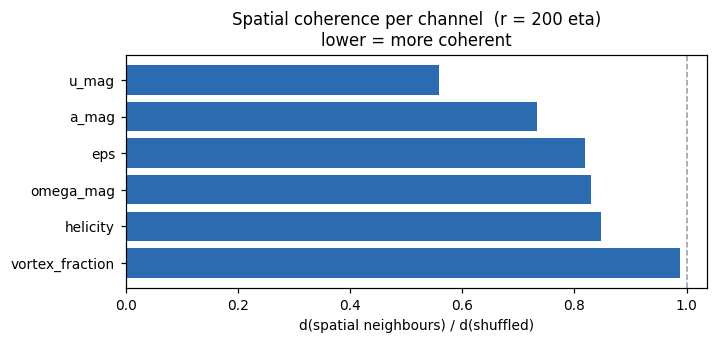

Observed order (most -> least coherent):
  u_mag  <  a_mag  <  eps  <  omega_mag  <  helicity  <  vortex_fraction

u_mag ratio = 0.559; next channel = 0.734
gap after u_mag = 0.175; spread among the rest = 0.254
-> no clear separation; inspect before claiming scale separation.


In [19]:
rows = []
for c in CHANNELS:
    DS, DN = [], []
    for k in TIMES:
        P = np.mod(X[:, k], L_BOX)
        v = CH[c][:, k]; v = (v - v.mean()) / v.std()
        pr = cKDTree(P, boxsize=L_BOX).query_pairs(RAD*eta, output_type="ndarray")
        if len(pr) == 0:
            continue
        pr = pr[TETRAD[pr[:, 0]] != TETRAD[pr[:, 1]]]
        if len(pr) < 5:
            continue
        DS.append(np.abs(v[pr[:, 0]] - v[pr[:, 1]]))
        p = RNG.permutation(N)
        DN.append(np.abs(v[p[pr[:, 0]]] - v[p[pr[:, 1]]]))
    DS, DN = np.concatenate(DS), np.concatenate(DN)
    rows.append(dict(channel=c, ratio=np.median(DS)/np.median(DN)))

perch = pd.DataFrame(rows).sort_values("ratio").reset_index(drop=True)
display(perch.round(3))

plt.figure(figsize=(6.6, 3.2))
plt.barh(perch.channel, perch.ratio, color="#2b6cb0")
plt.axvline(1.0, ls="--", c="0.6", lw=1)
plt.xlabel("d(spatial neighbours) / d(shuffled)")
plt.title(f"Spatial coherence per channel  (r = {RAD} eta)\nlower = more coherent")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

print("Observed order (most -> least coherent):")
print("  " + "  <  ".join(perch.channel))
gap = perch.ratio.iloc[1] - perch.ratio.iloc[0]
spread = perch.ratio.iloc[-1] - perch.ratio.iloc[1]
print(f"\nu_mag ratio = {perch.ratio.iloc[0]:.3f}; next channel = {perch.ratio.iloc[1]:.3f}")
print(f"gap after u_mag = {gap:.3f}; spread among the rest = {spread:.3f}")
print("-> velocity stands apart; the gradient-derived channels cluster, as predicted."
      if gap > spread else "-> no clear separation; inspect before claiming scale separation.")

## 8. The glyph

Rank-normalised, because `eps` and `|omega|` are heavy-tailed and a min-max scaling would
collapse almost every bead onto a stub.

Left pair: two particles that are **spatial neighbours** at the same instant, from different
tetrads. Their polygons should resemble one another -- that is claim 2 made visible.

Right pair: a deep vortex and a strong strain region, for contrast.

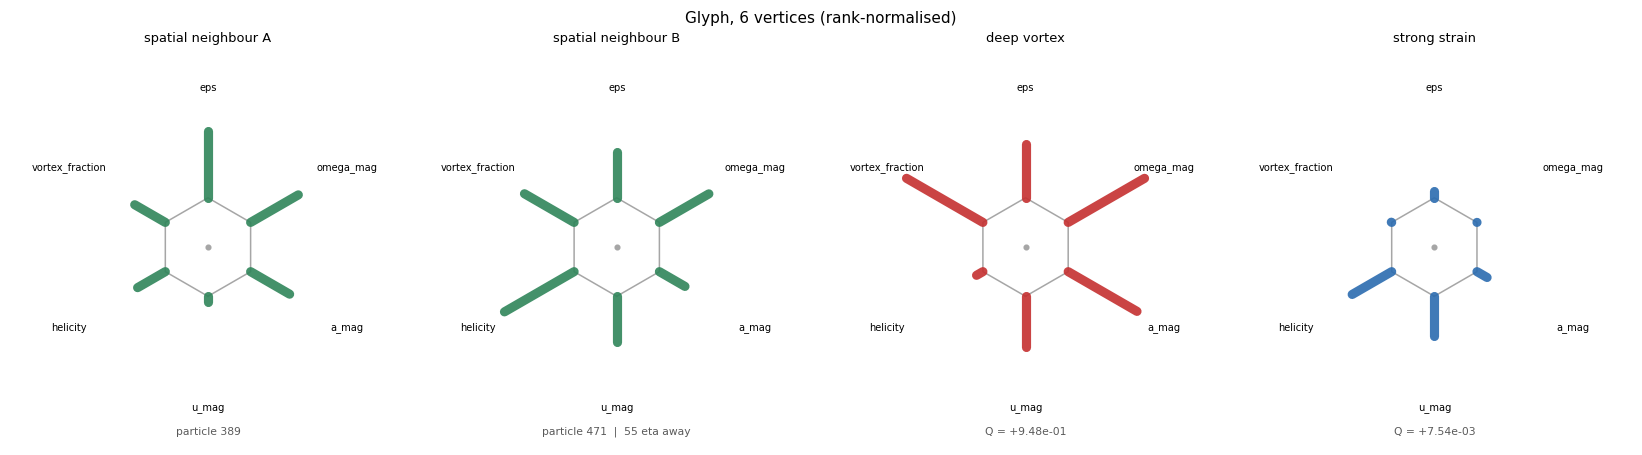

neighbour pair: 54.7 eta apart, tetrads 97 and 117
glyph shape distance = 1.992   (random-pair median ~ 2.614)


In [20]:
Rn = np.stack([rankdata(Cmat[:, j]) / len(Cmat) for j in range(len(CHANNELS))], axis=1)

def draw_glyph(ax, vals, title, color, sub=""):
    n = len(vals)
    ang = np.linspace(0, 2*np.pi, n, endpoint=False) - np.pi/2
    sx, sy = np.cos(ang), np.sin(ang)
    ax.plot(np.r_[sx, sx[0]], np.r_[sy, sy[0]], color="0.65", lw=1)
    ax.plot(0, 0, "o", ms=3, color="0.65")
    for a_, v, nm in zip(ang, vals, CHANNELS):
        r = 1 + 1.8*np.clip(v, 0, 1)
        ax.plot([np.cos(a_), r*np.cos(a_)], [np.sin(a_), r*np.sin(a_)],
                color=color, lw=6, solid_capstyle="round", alpha=.9)
        ax.text(3.25*np.cos(a_), 3.25*np.sin(a_), nm, ha="center", va="center", fontsize=6.5)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=8.5)
    if sub:
        ax.text(0, -3.8, sub, ha="center", fontsize=7, color="0.35")

# find a tight cross-tetrad spatial pair
kk = T - 1
P = np.mod(X[:, kk], L_BOX)
pr = cKDTree(P, boxsize=L_BOX).query_pairs(RADII_ETA[1]*eta, output_type="ndarray")
pr = pr[TETRAD[pr[:, 0]] != TETRAD[pr[:, 1]]]
d  = np.linalg.norm(np.minimum(np.abs(P[pr[:,0]]-P[pr[:,1]]),
                               L_BOX-np.abs(P[pr[:,0]]-P[pr[:,1]])), axis=1)
a_, b_ = pr[np.argmin(d)]
ga, gb = a_*T + kk, b_*T + kk

Qflat = CH["vortex_fraction"].ravel()
label = (Qflat > 0.5).astype(int) 
qi = np.argsort(Qflat)
i_strain, i_vortex = qi[len(qi)//200], qi[-len(qi)//200]

fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
draw_glyph(axes[0], Rn[ga], "spatial neighbour A", "#2f855a", f"particle {a_}")
draw_glyph(axes[1], Rn[gb], "spatial neighbour B", "#2f855a",
           f"particle {b_}  |  {d.min()/eta:.0f} eta away")
draw_glyph(axes[2], Rn[i_vortex], "deep vortex", "#c53030", f"Q = {Qflat[i_vortex]:+.2e}")
draw_glyph(axes[3], Rn[i_strain], "strong strain", "#2b6cb0", f"Q = {Qflat[i_strain]:+.2e}")
fig.suptitle(f"Glyph, {len(CHANNELS)} vertices (rank-normalised)", fontsize=10)
plt.tight_layout(); plt.show()

print(f"neighbour pair: {d.min()/eta:.1f} eta apart, tetrads {TETRAD[a_]} and {TETRAD[b_]}")
print(f"glyph shape distance = {np.linalg.norm(Zc[ga]-Zc[gb]):.3f}   "
      f"(random-pair median ~ {np.median(dr):.3f})")

## 9. The backbones in 3D

Several trajectories, coloured by `|omega|`. The tracers thread the same box; a bead's
spatial neighbours generally belong to *other* trajectories.

That is exactly the situation claim 2 describes, and the one a per-trajectory time-series
plot cannot express: it has one curve per particle and no shared spatial axis.

In [21]:
N_SHOW = 6
show = RNG.choice(N // TETRAD_SIZE, N_SHOW, replace=False) * TETRAD_SIZE
palette = ["#c53030", "#2b6cb0", "#2f855a", "#b7791f", "#6b46c1", "#00838f"]

g = go.Figure()
for c, i in zip(palette, show):
    g.add_trace(go.Scatter3d(
        x=X[i, ::4, 0], y=X[i, ::4, 1], z=X[i, ::4, 2],
        mode="lines", line=dict(color=c, width=3),
        name=f"particle {i}"))

# mark a cross-trajectory spatial neighbour pair at the final snapshot
kk = T - 1
P  = np.mod(X[:, kk], L_BOX)
pr = cKDTree(P, boxsize=L_BOX).query_pairs(RADII_ETA[1]*eta, output_type="ndarray")
pr = pr[TETRAD[pr[:, 0]] != TETRAD[pr[:, 1]]]
if len(pr):
    d  = np.linalg.norm(np.minimum(np.abs(P[pr[:,0]]-P[pr[:,1]]),
                                   L_BOX-np.abs(P[pr[:,0]]-P[pr[:,1]])), axis=1)
    a_, b_ = pr[np.argmin(d)]
    g.add_trace(go.Scatter3d(
        x=X[[a_, b_], kk, 0], y=X[[a_, b_], kk, 1], z=X[[a_, b_], kk, 2],
        mode="markers", marker=dict(size=6, color="black", symbol="diamond"),
        name=f"spatial neighbours ({d.min()/eta:.0f} eta apart)"))

g.update_layout(height=700,
                title="TURB-Lagr tracers: one colour per particle",
                scene=dict(aspectmode="data", xaxis_title="x",
                           yaxis_title="y", zaxis_title="z"))
g.show()

In [22]:
# ============================================================
# Export: all trajectories + per-bead glyph channels -> JSON
# ============================================================
# One object = one tracer particle. One point = one timestep.
# This cell can export either:
# - one particle per tetrad (USE_TETRAD_SAMPLE = True)
# - every particle in the subset (USE_TETRAD_SAMPLE = False)

# ---- knobs ----
OUT               = "turb_glyph.json"
USE_TETRAD_SAMPLE = True       # True = keep one particle per tetrad; False = export all particles
STRIDE            = 20          # keep every Nth timestep -> fewer points per path
SNAPSHOT          = None        # set to an int (e.g. 1500) to export one instant instead
WRAP              = False       # fold into [0, 2pi); required for periodic adjacency
NORMALIZE         = "rank"     # "rank" (empirical CDF) or "minmax"
DECIMALS          = 4

# ---- select particles ----
if USE_TETRAD_SAMPLE:
    idx = np.arange(0, N, TETRAD_SIZE)
else:
    idx = np.arange(N)

if SNAPSHOT is not None:
    tsel = np.array([SNAPSHOT])
else:
    tsel = np.arange(0, T, STRIDE)

Xs = X[np.ix_(idx, tsel)]                                    # (n, P, 3)
raw = np.stack([CH[c][np.ix_(idx, tsel)] for c in CHANNELS], axis=-1)   # (n, P, 6)

# ---- normalize globally, not per object, so fin lengths are comparable ----
# eps, a_mag and omega_mag are near log-normal. minmax puts most beads on a
# stub; rank keeps them spread.
n, P, C = raw.shape
flat = raw.reshape(-1, C)
vals = np.empty_like(flat)
for j in range(C):
    v = flat[:, j]
    if NORMALIZE == "rank":
        vals[:, j] = v.argsort().argsort() / max(1, len(v) - 1)
    else:
        r = np.ptp(v)
        vals[:, j] = (v - v.min()) / r if r > 0 else 0.0
vals = vals.reshape(n, P, C)

if WRAP:
    Xs = np.mod(Xs, L_BOX)

Xr, Vr = np.round(Xs, DECIMALS), np.round(vals, DECIMALS)

objects = [{
    "objectId": k,
    "label": f"particle-{int(pid)}",
    "points": [{"x": float(Xr[k, t, 0]), "y": float(Xr[k, t, 1]), "z": float(Xr[k, t, 2]),
                "values": Vr[k, t].tolist()} for t in range(P)],
} for k, pid in enumerate(idx)]

doc = {
    "meta": {
        "title": "TURB-Lagr Lagrangian tracers",
        "description": (
            "One object per tracer particle in a DNS of homogeneous isotropic turbulence "
            "(Re_lambda = 2310, 1024^3, triply periodic box of side 2*pi). Each point is a "
            "timestep along the particle path; values are six turbulence diagnostics driving "
            "the radar glyph. Because the flow is homogeneous and isotropic, the channels are "
            "statistically independent of position (max |r| = 0.072 against any spatial axis, "
            "effective rank 5/6), so glyph shape encodes flow structure rather than location."
        ),
        "unit": "dimensionless (channels rank-normalized to [0,1])",
        "source": "http://smart-turb.roma2.infn.it",
        "nu": NU,
        "boxSize": round(L_BOX, 6),
        "eta": float(eta),
        "tauEta": float(tau_eta),
        "coordinates": "wrapped into [0, 2pi)" if WRAP else "unwrapped",
        "nObjects": len(objects),
        "nPointsPerObject": int(P),
        "tetradSample": USE_TETRAD_SAMPLE,
    },
    "channels": CHANNELS,
    "objects": objects,
}

with open(OUT, "w") as f:
    json.dump(doc, f, separators=(",", ":"))

print(f"wrote {OUT}: {len(objects)} objects x {P} points = {len(objects)*P:,} beads, "
      f"{os.path.getsize(OUT)/1e6:.2f} MB")
print(f"  tetrad_sample={USE_TETRAD_SAMPLE}  normalize={NORMALIZE}  wrap={WRAP}  snapshot={SNAPSHOT}")
if WRAP and SNAPSHOT is None:
    print("  NOTE: paths jump at box faces. Break segments longer than L/2 when rendering.")

wrote turb_glyph.json: 125 objects x 100 points = 12,500 beads, 1.11 MB
  tetrad_sample=True  normalize=rank  wrap=False  snapshot=None


In [24]:
print(f"corr(helicity, omega_mag) = {Rch[CHANNELS.index('helicity'), CHANNELS.index('omega_mag')]:.3f}")
print(f"corr(helicity, u_mag)     = {Rch[CHANNELS.index('helicity'), CHANNELS.index('u_mag')]:.3f}")

corr(helicity, omega_mag) = 0.018
corr(helicity, u_mag)     = -0.016
